# GBPUSD/EURUSD — independent-day strategies

Four strategies on the cointegration spread, fit and back-tested **independently per trading day** on three months: **2024-08, 2024-09, 2025-08**.

### Pipeline (paper §2–§4)
1. **Pre-averaging** (paper eq 2.2): bid/ask ticks of leg A and leg B are synchronised at the tick level (union + ffill), then every L=200 consecutive synchronised ticks are collapsed into one bar by averaging the mids. Same L, same boundaries on both legs → pre-averaged legs perfectly co-time.
2. **Rolling cointegration** (paper §3.1): hedge ratio $\beta_t$ by rolling OLS with window $W_\beta=50$ on the pre-averaged log prices; spread $S_t = \log P^A_t - \beta_t \log P^B_t - \alpha_t$.
3. **Rolling $z$-score** (paper §3.2): $Z_t$ over $W_z=25$ bars.
4. **MS-AR(1) on the spread** (paper §4.3): EM via Baum–Welch, $K=2$, multi-seed init.
5. **Regime labelling by innovation variance** (paper §4.7): MR = regime with smallest $\sigma^{(k)}$ (quiet, safe), DR = regime with largest $\sigma^{(k)}$ (volatile, danger).
6. **Four strategies**: Buy & Hold, Baseline (z-score), AR (binary gate $\mathbf{1}\{\gamma_t^{MR} \geq 1-\delta\}$), MS-AR (dynamic threshold $\gamma_t^{MR} z_q + \gamma_t^{DR} z_v$).

The OOS forward filter is intentionally deferred — we use the in-sample smoothed posteriors $\gamma_t^{MR}$ directly inside the strategies, so this is a *best-case* picture of how the regime information would be used if it were known.


In [5]:
# Colab bootstrap (silently skipped on local environments).
import importlib.util, sys, os
if importlib.util.find_spec('google.colab') is not None:
    import subprocess
    subprocess.run(
        ['curl', '-sL',
         'https://raw.githubusercontent.com/egil10/stk-mat2011/main/code/scripts/colab.py',
         '-o', '/content/colab.py'],
        check=True,
    )
    sys.path.insert(0, '/content')
    from colab import setup
    setup('code/strats')
else:
    sys.path.insert(0, os.path.abspath('../scripts'))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CWD           : /content/stk-mat2011/code/strats
Scripts path  : /content/stk-mat2011/code/scripts
Data symlink  : /content/stk-mat2011/code/data/processed -> /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/data/processed
Parquet files : 916


In [6]:
%pip install --quiet arch statsmodels numba optuna


In [7]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from spread import SPREAD
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET

PAIR_A, PAIR_B = 'GBPUSD', 'EURUSD'
MONTHS         = ['202408', '202409', '202508']
DATA_DIR       = '../data/processed'

# Tick-synced pre-averaged bars (paper eq 2.2).
# L=200 -> each bar is the mean of 200 SYNCHRONISED ticks on both legs.
BAR_CFG = dict(
    agg_type     = 'tick',
    threshold    = 200,       # block size L
    price_agg    = 'mean',    # 'mean' triggers tick-sync + pre-averaging
    active_hours = (0, 24),
)

# Per-day fit: rolling beta, rolling z-score, MS-AR(1) on the day's spread.
FIT_CFG = dict(
    coint_window  = 50,    # W_beta
    z_window      = 25,    # W_z
    k_regimes     = 2,
    winsorize_std = 4.0,
    scaling       = 10000,
    n_init        = 3,
)

# Strategies (paper sections on regime-aware trading).
STRAT_CFG = dict(
    z_quiet          = 1.3,
    z_volatile       = 2.5,
    exit_z           = 0.0,
    danger_threshold = 0.30,
    fee_bps          = 0.5,
    slippage_mode    = 'half_spread',
    flatten_eod      = True,
    prob_smoothing   = 0,
)

ANN_FACTOR = 252 * 24 * 60   # tick-clock annualisation


## Per-month run

For each month we

1. Aggregate raw bid/ask ticks into L-tick pre-averaged bars (`SPREAD`).
2. Fit each trading day independently — rolling cointegration ($\beta_t, \alpha_t$), rolling $z$-score, MS-AR(1) on the day's spread (`ENGINE.each_day`). Regimes labelled by $\sigma$.
3. Run Buy & Hold, Baseline, AR(1) gate, MS-AR(1) dynamic-threshold through the same back-test machinery (`BACKTESTER`).
4. Score with `TEARSHEET`.


In [8]:
def files(pair, month):
    p = pair.lower()
    return (
        [f'{DATA_DIR}/{p}_dukascopy_ask_{month}.parquet'],
        [f'{DATA_DIR}/{p}_dukascopy_bid_{month}.parquet'],
    )


def fmt_pnl(bt):
    return {s: bt[f'Return_{s}'].fillna(0).sum() * 1e4
            for s in ['BuyHold', 'Baseline', 'AR', 'MS_AR']}


runs = {}
for m in MONTHS:
    print(f'\n=== {m}  {PAIR_A}/{PAIR_B} ===')

    ask_a, bid_a = files(PAIR_A, m)
    ask_b, bid_b = files(PAIR_B, m)

    df = SPREAD(**BAR_CFG).build([ask_a, bid_a, ask_b, bid_b], verbose=True)
    n_bars = len(df)
    n_days = df.index.normalize().unique().shape[0]
    print(f'  {n_bars:,} pre-averaged bars over {n_days} trading days')

    fitted, params = ENGINE.each_day(df, **FIT_CFG, verbose=True)
    bt = BACKTESTER(fitted).run(**STRAT_CFG)
    runs[m] = (bt, params, fitted)

    pnl = fmt_pnl(bt)
    bh, base, ar, ms = pnl['BuyHold'], pnl['Baseline'], pnl['AR'], pnl['MS_AR']
    print(
        f'  net pnl (bps):  BH={bh:+8.1f}  Base={base:+8.1f}  '
        f'AR={ar:+8.1f}  MS-AR={ms:+8.1f}'
    )



=== 202408  GBPUSD/EURUSD ===
built 8677 rows
  8,677 pre-averaged bars over 22 trading days
Each-day fit | coint_window=50 | z_window=25 | k_regimes=2 | winsor=4.0σ | scale=x10000 | n_init=3 | days=22
  net pnl (bps):  BH=   -41.0  Base=  -522.4  AR=  -246.0  MS-AR=  -152.0

=== 202409  GBPUSD/EURUSD ===
built 9547 rows
  9,547 pre-averaged bars over 21 trading days
Each-day fit | coint_window=50 | z_window=25 | k_regimes=2 | winsor=4.0σ | scale=x10000 | n_init=3 | days=21
  net pnl (bps):  BH=  +127.9  Base=  -439.7  AR=  -295.9  MS-AR=  -193.1

=== 202508  GBPUSD/EURUSD ===
built 7213 rows
  7,213 pre-averaged bars over 21 trading days
Each-day fit | coint_window=50 | z_window=25 | k_regimes=2 | winsor=4.0σ | scale=x10000 | n_init=3 | days=21
  net pnl (bps):  BH=    +9.7  Base=  -347.2  AR=  -109.9  MS-AR=   -70.5


## Per-month tearsheets



============================  202408  ============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | -41.03         | -522.38        | -245.97        | -152.00        |
Annual Return (bps)            | -516.81        | -6579.28       | -3097.98       | -1914.36       |
Best Month (bps)               | -41.03         | -522.38        | -245.97        | -152.00        |
Worst Month (bps)              | -41.03         | -522.38        | -245.97        | -152.00        |
Positive Months %              | 0.00%          | 0.00%          | 0.00%          | 0.00%          |

--- RISK ---
Annual Volatility (bps)        | 594.85         | 474.18         | 213.36         | 346.75         |
Max Dra

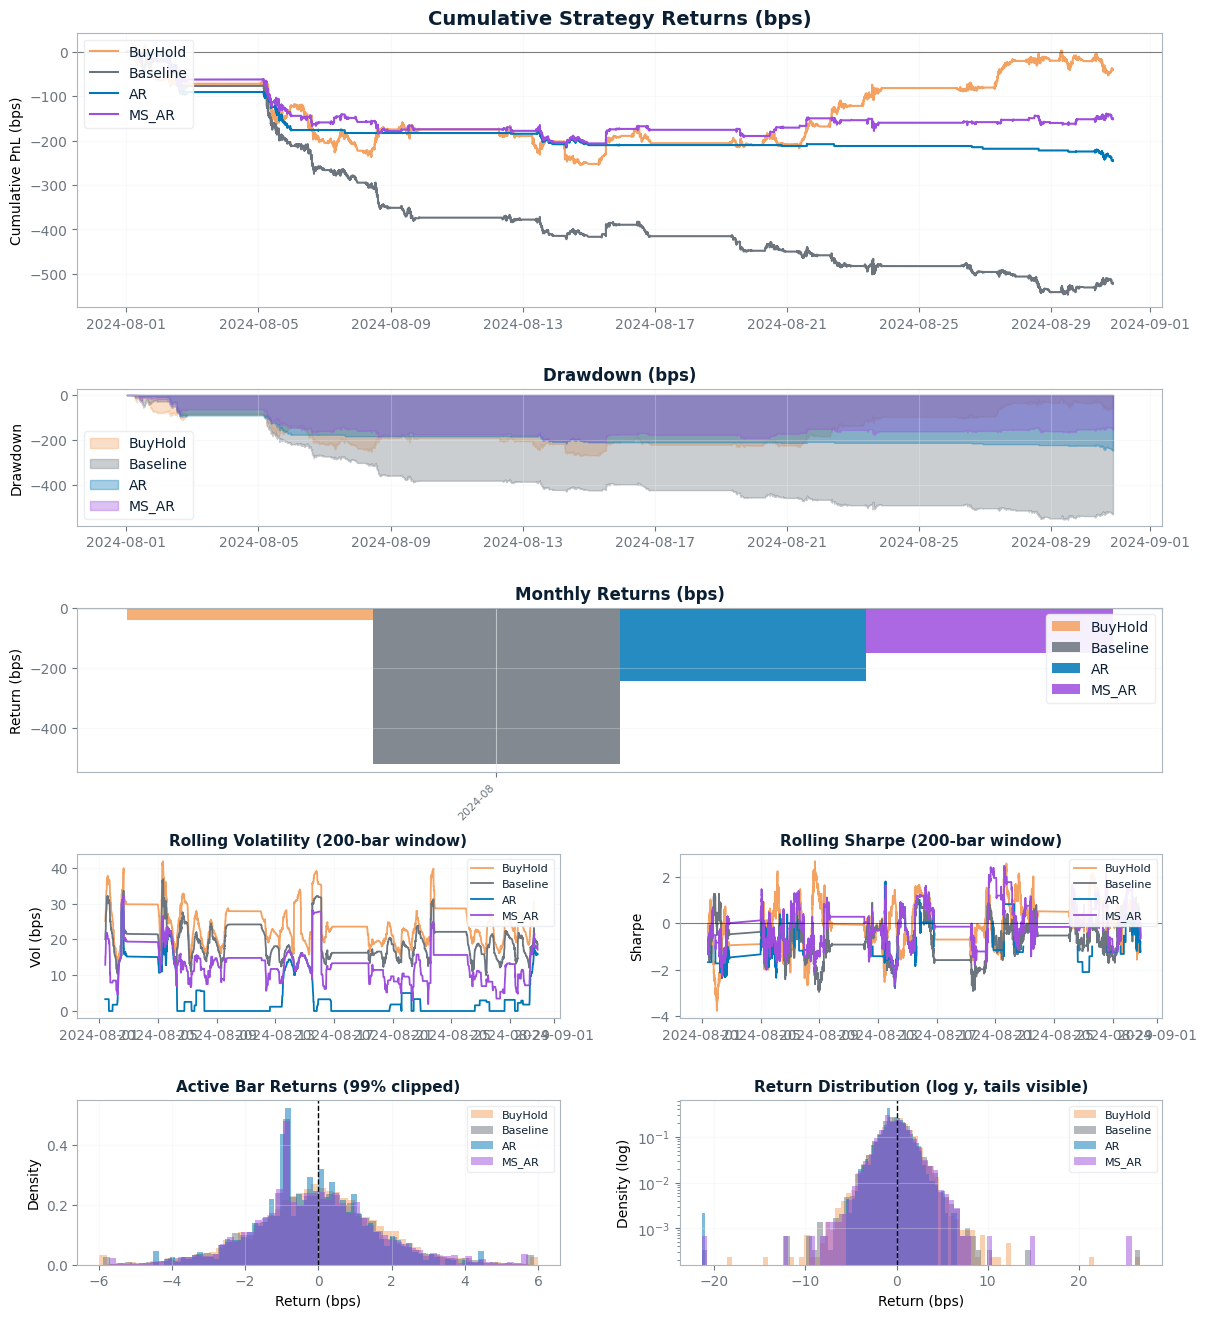

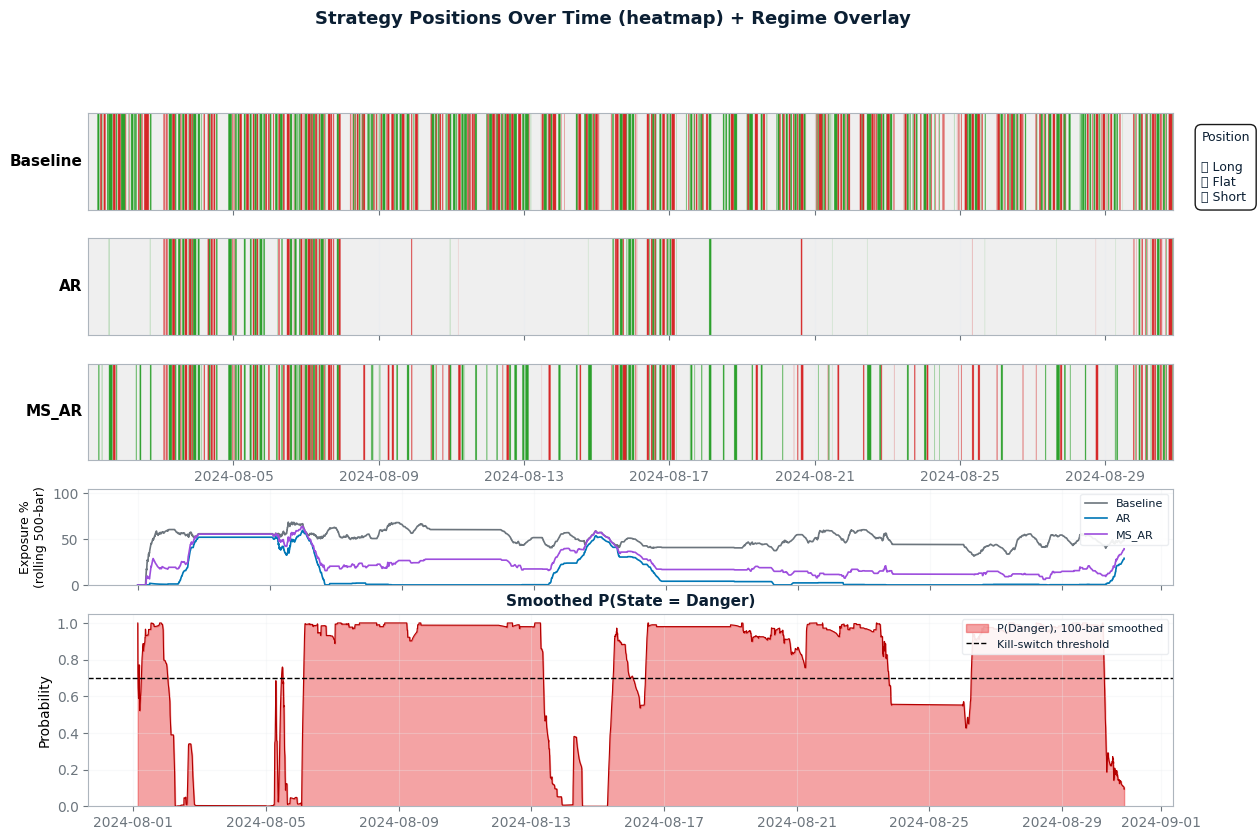

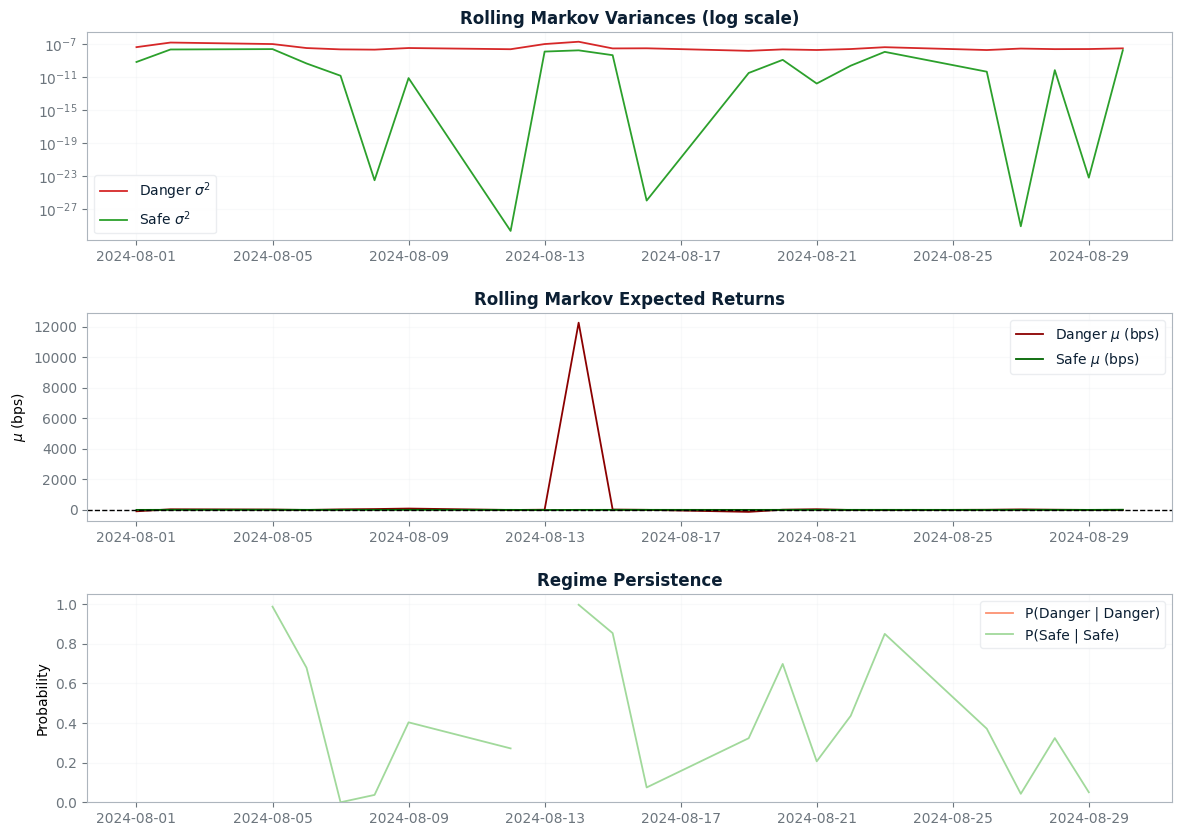


============================  202409  ============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | 127.88         | -439.66        | -295.88        | -193.07        |
Annual Return (bps)            | 1668.21        | -5735.27       | -3859.67       | -2518.56       |
Best Month (bps)               | 127.88         | -439.66        | -295.88        | -193.07        |
Worst Month (bps)              | 127.88         | -439.66        | -295.88        | -193.07        |
Positive Months %              | 100.00%        | 0.00%          | 0.00%          | 0.00%          |

--- RISK ---
Annual Volatility (bps)        | 555.50         | 438.94         | 199.61         | 320.67         |
Max Dra

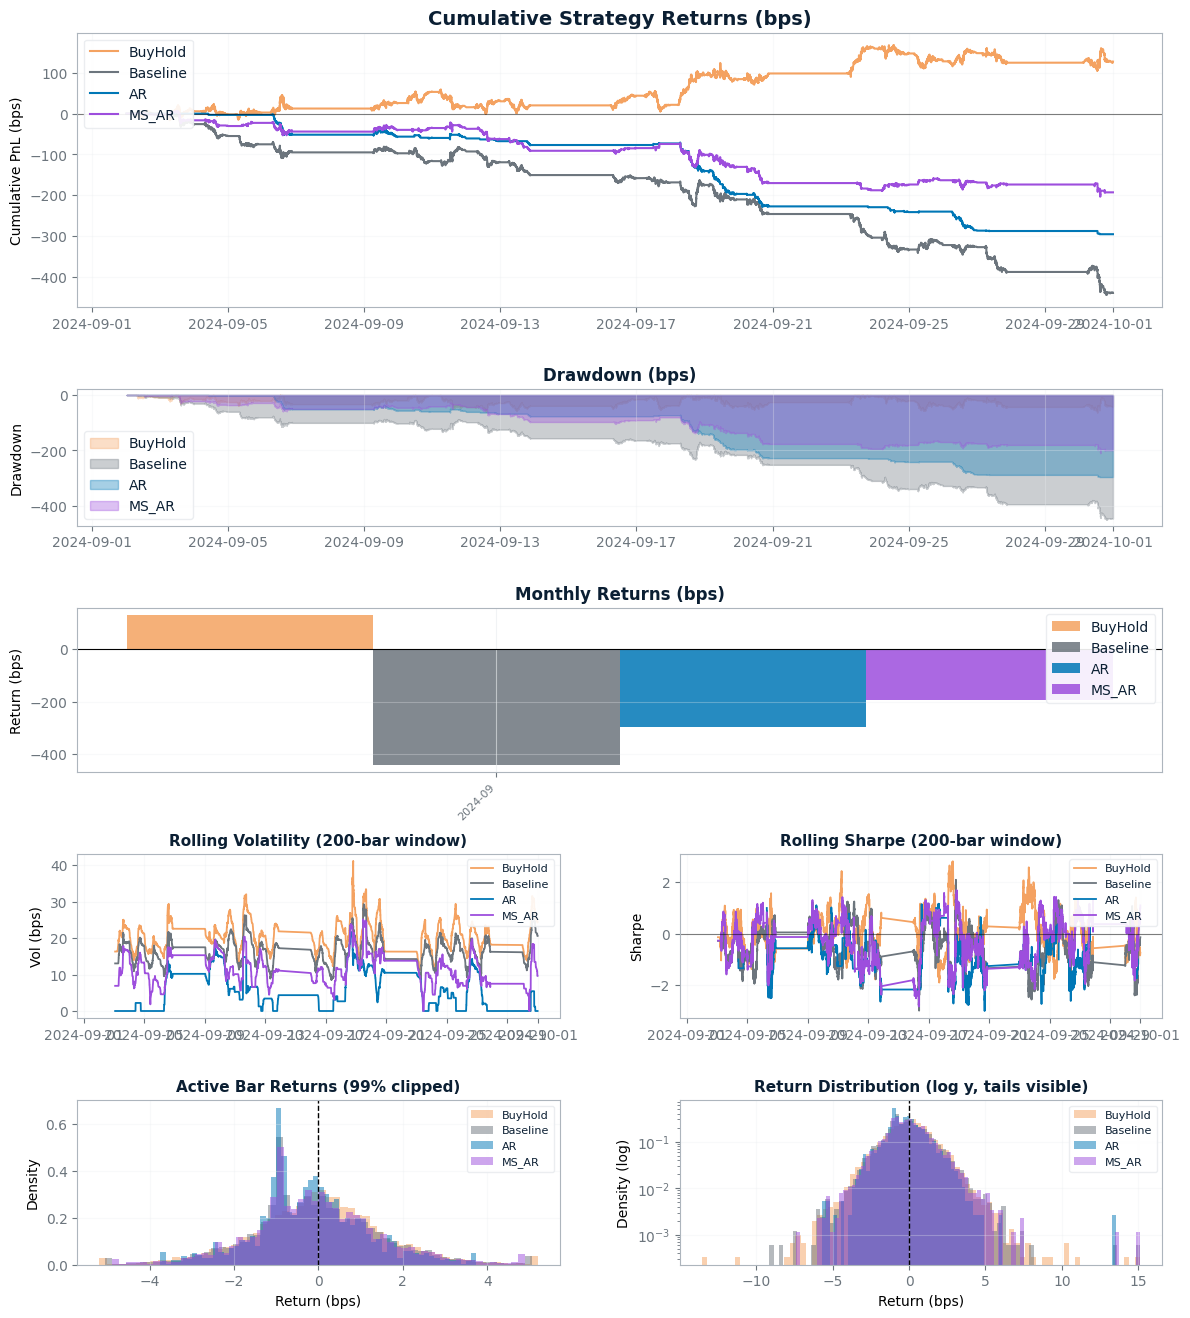

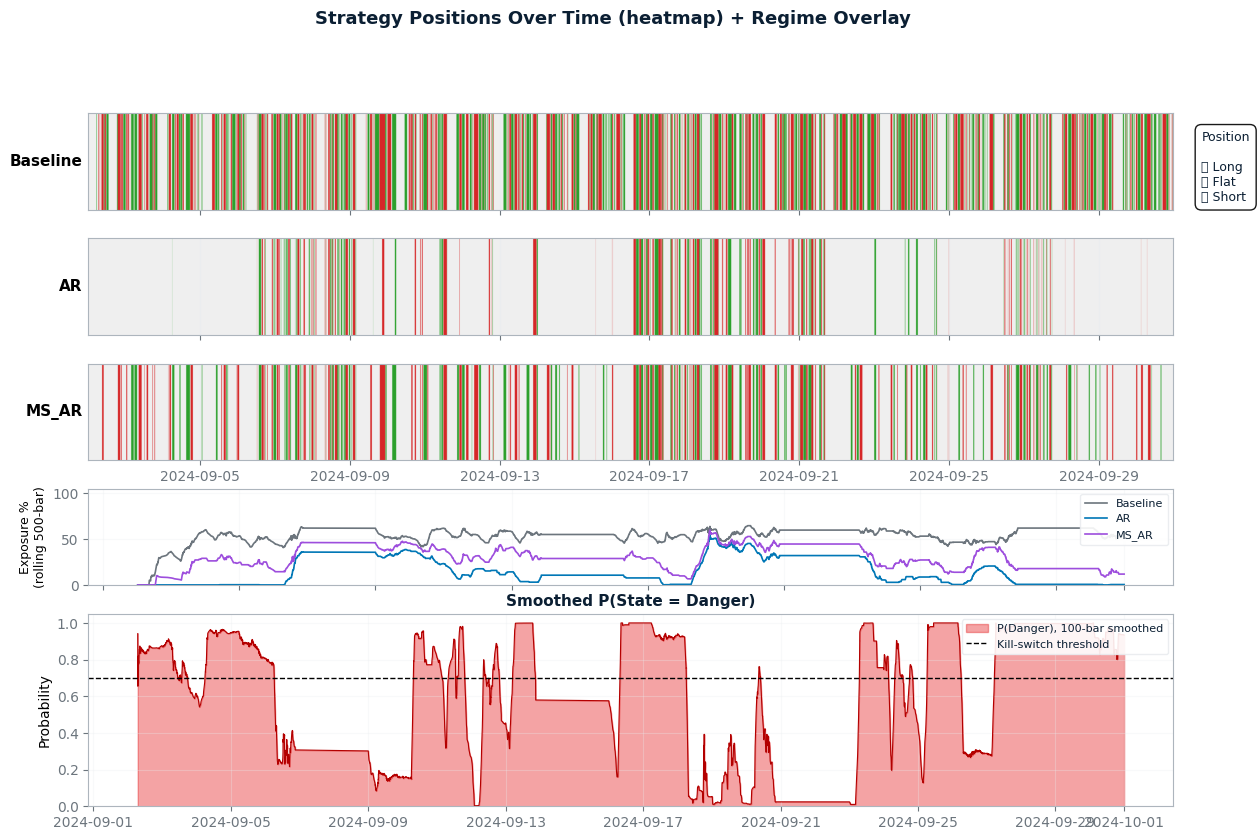

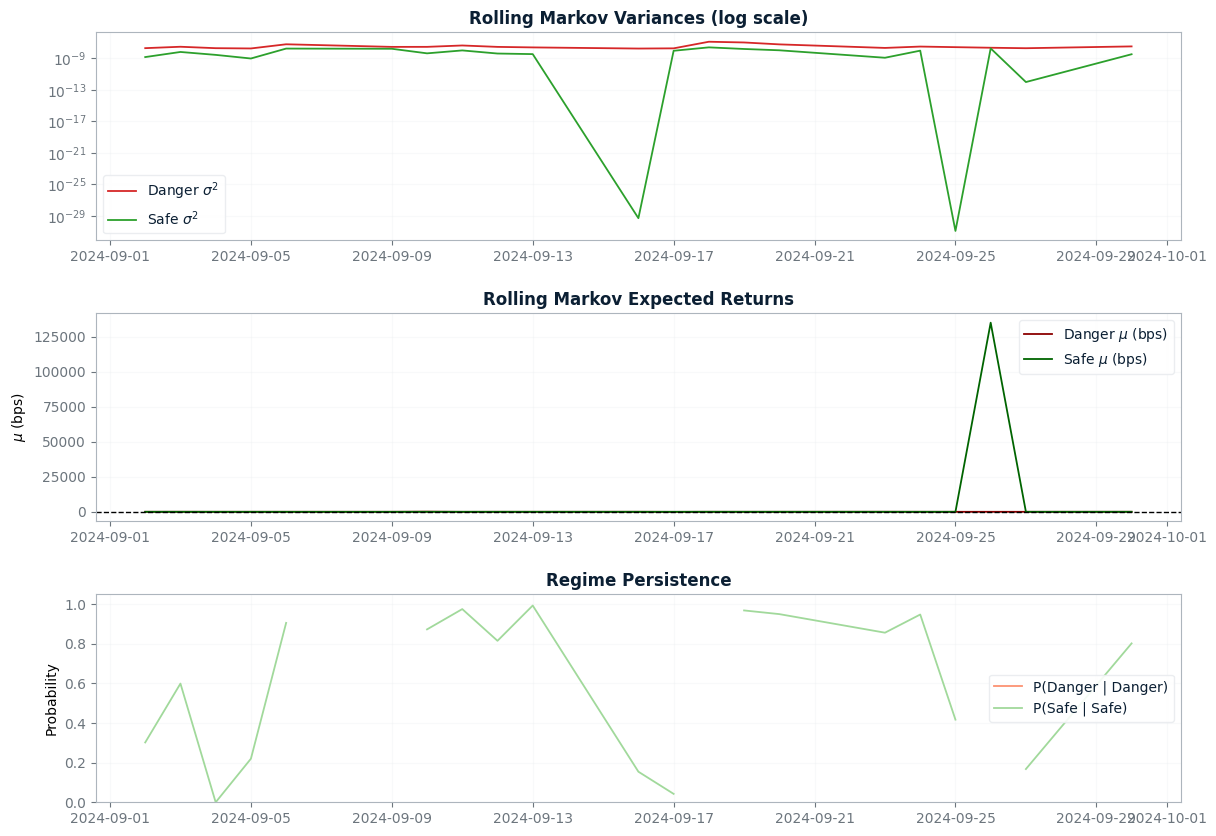


============================  202508  ============================

                           QUANTITATIVE STRATEGY TEARSHEET                           
Metric                         | BuyHold        | Baseline       | AR             | MS_AR          |
----------------------------------------------------------------------------------------------------

--- RETURN ---
Total Return (bps)             | 9.69           | -347.17        | -109.93        | -70.49         |
Annual Return (bps)            | 126.38         | -4528.73       | -1433.97       | -919.57        |
Best Month (bps)               | 9.69           | -347.17        | -109.93        | -70.49         |
Worst Month (bps)              | 9.69           | -347.17        | -109.93        | -70.49         |
Positive Months %              | 100.00%        | 0.00%          | 0.00%          | 0.00%          |

--- RISK ---
Annual Volatility (bps)        | 516.00         | 413.76         | 183.75         | 278.72         |
Max Dra

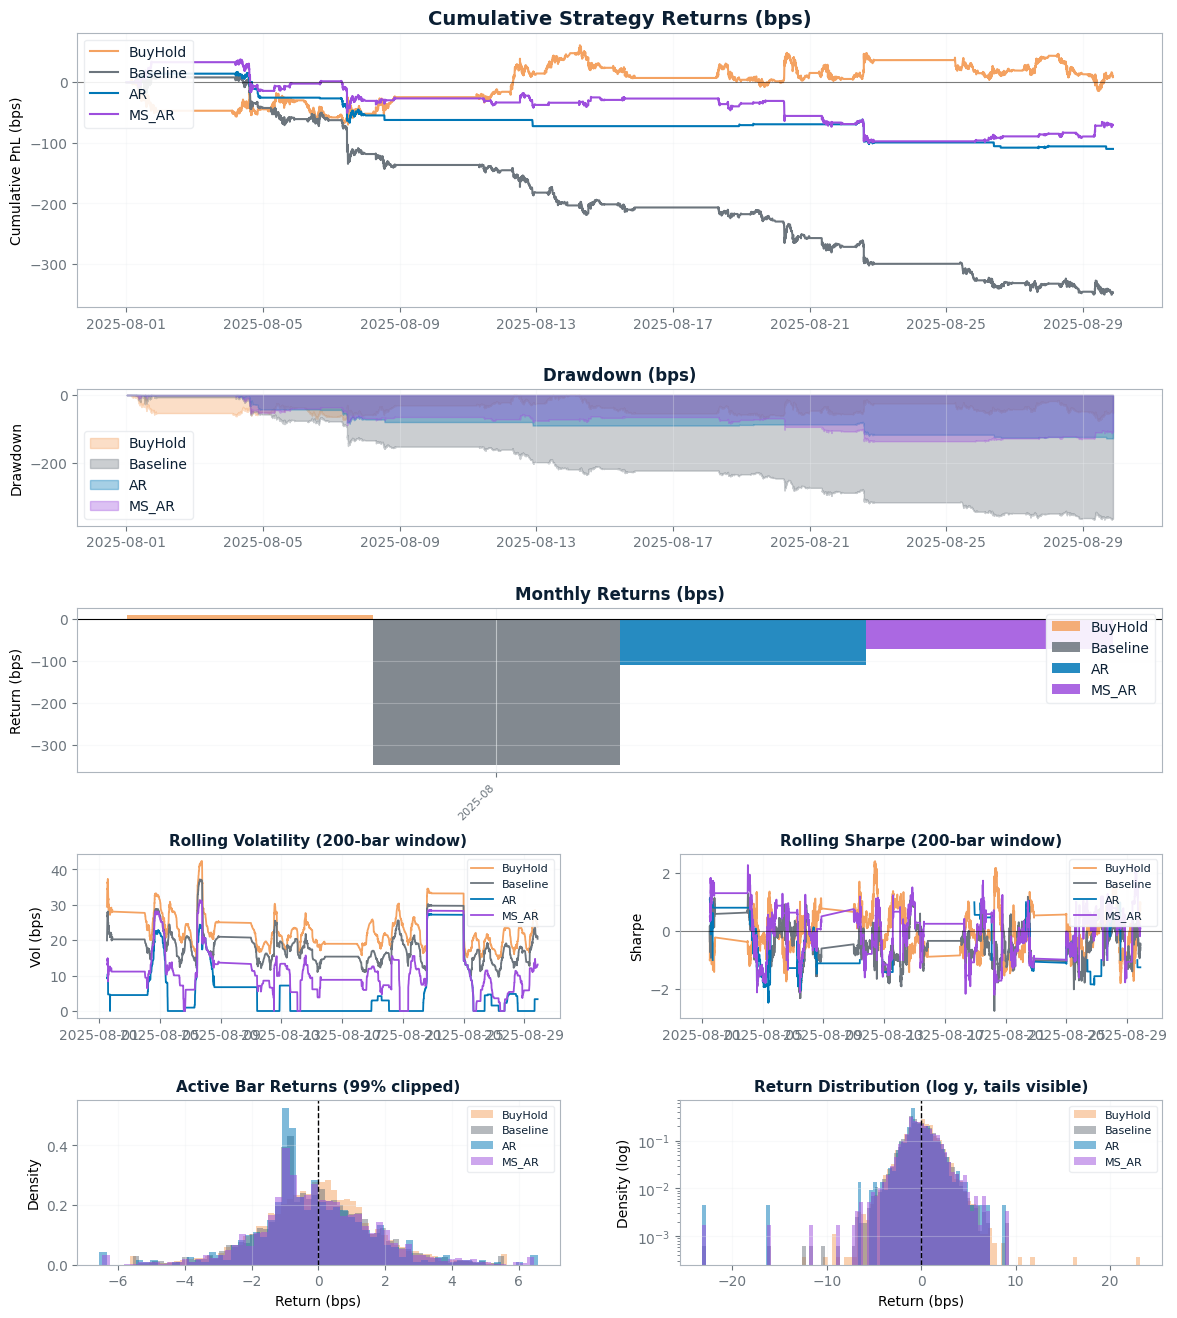

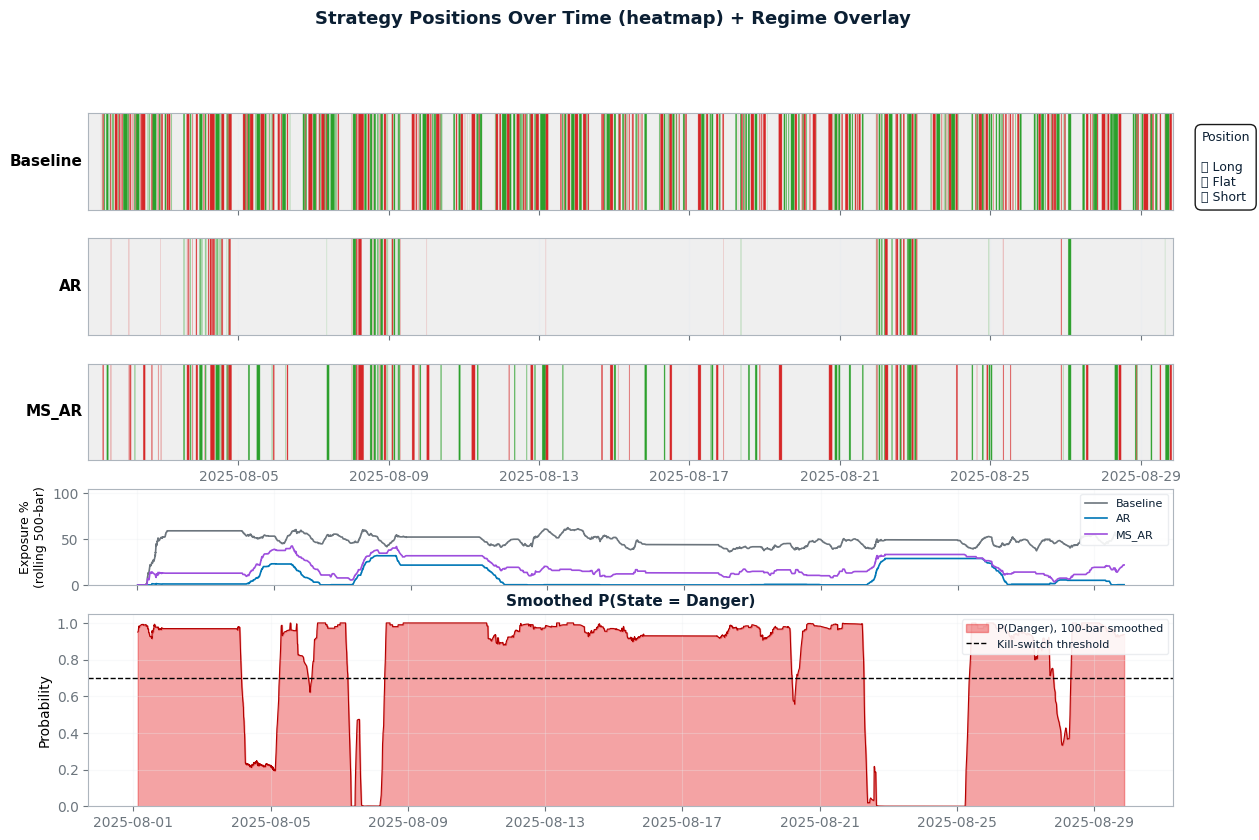

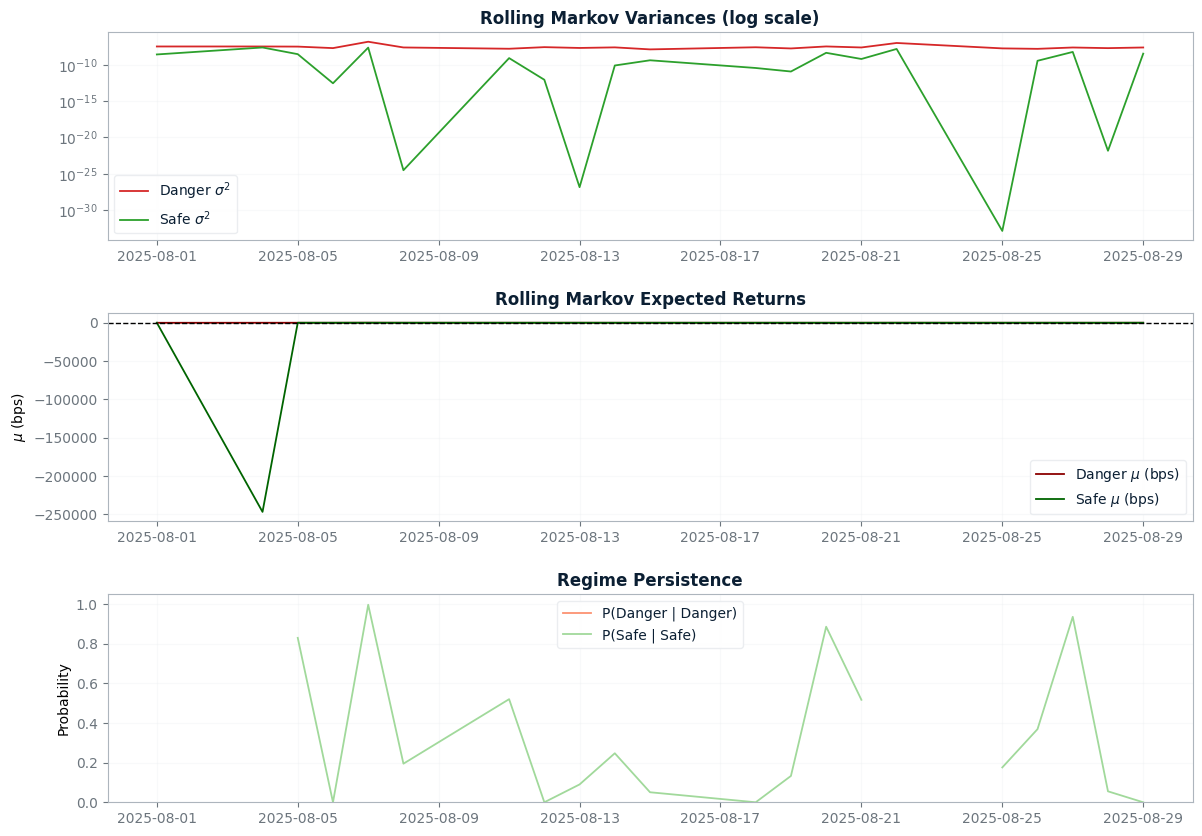

In [9]:
for m, (bt, params, _) in runs.items():
    print(f'\n{"="*28}  {m}  {"="*28}')
    ts = TEARSHEET(bt, df_params=params)
    ts.generate_report()
    ts.plot_performance()
    ts.plot_positions_and_regimes()
    ts.plot_markov_dynamics()


## Cross-month summary

PnL in bps, Sharpe annualised on the tick-clock (`252 × 24 × 60` bars/year, matches `MONTH` default), and one round-trip per `Target` flip cycle.


In [10]:
def annualised_sharpe(returns):
    r = returns.fillna(0)
    sd = r.std()
    return float(r.mean() / sd * np.sqrt(ANN_FACTOR)) if sd > 0 else 0.0


rows = []
for m, (bt, _, _) in runs.items():
    row = {'Month': m}
    for s in ['BuyHold', 'Baseline', 'AR', 'MS_AR']:
        r = bt[f'Return_{s}']
        row[f'{s}_PnL_bps'] = float(r.fillna(0).sum() * 1e4)
        row[f'{s}_Sharpe']  = annualised_sharpe(r)
        row[f'{s}_Trades']  = int((bt[f'Target_{s}'].diff().abs() > 0).sum() / 2)
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Month')

print('\n=== PnL bps by month ===')
print(summary[[c for c in summary.columns if c.endswith('PnL_bps')]].round(1).to_string())

print('\n=== Sharpe (tick-clock annualised) ===')
print(summary[[c for c in summary.columns if c.endswith('Sharpe')]].round(2).to_string())

print('\n=== Round-trip trade counts ===')
print(summary[[c for c in summary.columns if c.endswith('Trades')]].to_string())

summary



=== PnL bps by month ===
        BuyHold_PnL_bps  Baseline_PnL_bps  AR_PnL_bps  MS_AR_PnL_bps
Month                                                               
202408            -41.0            -522.4      -246.0         -152.0
202409            127.9            -439.7      -295.9         -193.1
202508              9.7            -347.2      -109.9          -70.5

=== Sharpe (tick-clock annualised) ===
        BuyHold_Sharpe  Baseline_Sharpe  AR_Sharpe  MS_AR_Sharpe
Month                                                           
202408           -1.58           -25.28     -26.46        -10.06
202409            5.13           -22.30     -33.01        -13.41
202508            0.48           -21.50     -15.33         -6.48

=== Round-trip trade counts ===
        BuyHold_Trades  Baseline_Trades  AR_Trades  MS_AR_Trades
Month                                                           
202408               0              422        120           201
202409               0              

,BuyHold_PnL_bps,BuyHold_Sharpe,BuyHold_Trades,Baseline_PnL_bps,Baseline_Sharpe,Baseline_Trades,AR_PnL_bps,AR_Sharpe,AR_Trades,MS_AR_PnL_bps,MS_AR_Sharpe,MS_AR_Trades
Month,,,,,,,,,,,,
202408,-41.033721,-1.583160,0,-522.379270,-25.283357,422,-245.972626,-26.458163,120,-151.995744,-10.060132,201
202409,127.884347,5.126193,0,-439.664789,-22.304060,520,-295.881724,-33.007051,211,-193.072344,-13.406618,256
202508,9.688242,0.480992,0,-347.171689,-21.495066,390,-109.927823,-15.325688,92,-70.493866,-6.479247,136


### Per-day regime parameters

Each row in `runs[m][1]` is the per-day fit summary: bar count, $\beta$, regime $\sigma$, regime $\rho$, regime means and transition probabilities. Useful for sanity-checking the HMM and for the paper's tables.


In [11]:
for m, (_, params, _) in runs.items():
    print(f'\n=== {m}  per-day fits ===')
    print(params.round(4).to_string())



=== 202408  per-day fits ===
            Bars    Beta   Alpha  Safe_Variance  Danger_Variance  Safe_Mean  Danger_Mean  P_Safe_Safe  P_Danger_Danger  MR_Rho  DR_Rho
Date                                                                                                                                  
2024-08-01   518  0.9220  0.1717            0.0              0.0    -0.0003      -0.0094       0.8336              NaN  0.4487  0.9522
2024-08-02   523  1.5655  0.1105            0.0              0.0     0.0001       0.0037          NaN           0.9254  0.9465  0.9140
2024-08-05   980 -0.0669  0.2515            0.0              0.0     0.0005       0.0021       0.9872              NaN  0.9468  0.9076
2024-08-06   624  0.8658  0.1614            0.0              0.0     0.0001      -0.0008       0.6787              NaN  0.3684  0.9296
2024-08-07   466 -0.7830  0.3075            0.0              0.0     0.0000       0.0031       0.0000              NaN -0.1016  0.9545
2024-08-08   434 -0.0382 